# TF-IDF and PMI Weighted Representations

## Imports and configuration

In [38]:
import os
import re
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Part 1 configuration
# -----------------------------
BASE_DIR = "."  # keep notebook in same folder as cleaned.txt, raw.txt, metadata.json

CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
RAW_PATH = os.path.join(BASE_DIR, "raw.txt")
META_PATH = os.path.join(BASE_DIR, "metadata.json")

MAX_VOCAB = 10000
UNK_TOKEN = "<UNK>"

WINDOW_SIZE = 5
NEGATIVE_SAMPLES = 10
EMBED_DIM = 100
LR = 1e-3
BATCH_SIZE = 1024   # >= 512 as required
EPOCHS = 5

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 11

Using device: cuda


## Load and parse the files

In [37]:
def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_numbered_blocks(text):
    """
    Parses blocks like:
    [1]
    content...
    [2]
    content...
    """
    pattern = re.compile(r"\[(\d+)\]\s*(.*?)(?=\n\[\d+\]\s*|\Z)", re.DOTALL)
    blocks = {}
    for match in pattern.finditer(text):
        doc_id = match.group(1)
        content = match.group(2).strip()
        blocks[doc_id] = content
    return blocks

def extract_cleaned_sentences(block_text):
    """
    Extract sentences between <SOS> and <EOS>, return list of token lists.
    """
    sentences = re.findall(r"<SOS>\s*(.*?)\s*<EOS>", block_text, flags=re.DOTALL)
    out = []
    for sent in sentences:
        tokens = [tok.strip() for tok in sent.split() if tok.strip()]
        if tokens:
            out.append(tokens)
    return out

RAW_TOKEN_PATTERN = re.compile(r'[\u0600-\u06FF]+|[A-Za-z]+|\d+|[^\s]')

def raw_tokenize(text):
    return RAW_TOKEN_PATTERN.findall(text)

def extract_raw_sentences(block_text):
    """
    Lightweight raw sentence splitter.
    """
    parts = re.split(r"[۔!?]+", block_text)
    sentences = []
    for part in parts:
        tokens = raw_tokenize(part)
        if tokens:
            sentences.append(tokens)
    return sentences

print("Helper functions loaded successfully.")


cleaned_text = read_text(CLEANED_PATH)
raw_text = read_text(RAW_PATH)
metadata = read_json(META_PATH)

cleaned_blocks = parse_numbered_blocks(cleaned_text)
raw_blocks = parse_numbered_blocks(raw_text)

common_ids = sorted(
    set(cleaned_blocks.keys()) & set(raw_blocks.keys()) & set(metadata.keys()),
    key=lambda x: int(x)
)

articles = []
for doc_id in common_ids:
    cleaned_sentences = extract_cleaned_sentences(cleaned_blocks[doc_id])
    cleaned_tokens = [tok for sent in cleaned_sentences for tok in sent]

    raw_sentences = extract_raw_sentences(raw_blocks[doc_id])
    raw_tokens = [tok for sent in raw_sentences for tok in sent]

    articles.append({
        "id": doc_id,
        "title": metadata[doc_id].get("title", ""),
        "publish_date": metadata[doc_id].get("publish_date", ""),
        "cleaned_sentences": cleaned_sentences,
        "cleaned_tokens": cleaned_tokens,
        "raw_sentences": raw_sentences,
        "raw_tokens": raw_tokens,
    })

print("Aligned articles:", len(articles))
print("Sample article id:", articles[0]["id"])
print("Sample title:", articles[0]["title"])
print("Sample cleaned sentence:", articles[0]["cleaned_sentences"][0][:20])


Helper functions loaded successfully.
Aligned articles: 210
Sample article id: 1
Sample title: پنجاب کے ہسپتالوں میں ایمرجنسی میں کام کرنے والے طبّی عملے کے موبائل فون کے استعمال پر پابندی: ’حکومت وسائل دے، کارروائی کی دھمکی نہیں‘
Sample cleaned sentence: ['پاکستان', 'کے', 'صوبے', 'پنجاب', 'کی', 'وزیر', 'اعلی', 'مریم', 'نواز', 'نے', 'دو', 'روز', 'قبل', 'اپنے', 'ایکس', 'اکاونٹ', 'سے', 'ایک', 'پوسٹ', 'کی']


## Assign topic labels

In [39]:
# -----------------------------
# Topic assignment
# -----------------------------
TOPIC_KEYWORDS = {
    "politics": [
        "حکومت", "وزیر", "وزیراعظم", "پارلیمان", "اسمبلی", "انتخابات", "انتخاب",
        "سیاسی", "عمران", "نواز", "شہباز", "جماعت", "تحریک", "اپوزیشن", "قانون",
        "صدر", "وفاقی", "صوبائی", "بلدیاتی", "کابینہ", "سینیٹ", "رکن", "امیدوار",
        "سیٹ", "ووٹ", "الیکشن", "ریفرنڈم", "گورنر", "وزیراعلی", "مشیر", "بیان",
        "قرارداد", "تحریک انصاف", "مسلم لیگ", "پیپلز پارٹی", "متحدہ", "جلسہ", "دھرنا"
    ],

    "sports": [
        "کرکٹ", "میچ", "ٹیم", "کھلاڑی", "رنز", "کپ", "ورلڈ", "سرفراز",
        "فائنل", "سیمی", "وکٹ", "بال", "کھیل", "اسپورٹس",
        "اوور", "اننگز", "بیٹنگ", "بولنگ", "فیلڈنگ", "سنچری", "ہاف سنچری",
        "چھکا", "چوکا", "گول", "فٹبال", "ہاکی", "ٹورنامنٹ", "لیگ", "سیریز",
        "کپتان", "کوچ", "پاکستان کرکٹ بورڈ", "پی سی بی", "اسٹیڈیم", "اولمپکس"
    ],

    "economy": [
        "معیشت", "بجٹ", "بینک", "مہنگائی", "افراط", "تجارت", "برآمد", "درآمد",
        "سٹاک", "سرمایہ", "سونا", "حصص", "کمپنی", "نجکاری", "روپے", "ڈالر",
        "مارکیٹ", "قیمت", "ٹیکس", "محصول", "سبسڈی", "زرمبادلہ", "شرح سود",
        "اسٹیٹ بینک", "قرض", "آئی ایم ایف", "مالیاتی", "خسارہ", "ترسیلات",
        "معاشی", "کاروبار", "سرمایہ کاری", "مہنگا", "سستا", "کرنسی"
    ],

    "international": [
        "امریکہ", "روس", "چین", "بھارت", "ایران", "اسرائیل", "غزہ", "اقوام",
        "متحدہ", "یوکرین", "معاہدہ", "سفارتی", "بین الاقوامی", "ترکمانستان", "یو اے ای",
        "افغانستان", "سعودی", "قطر", "ترکی", "یورپ", "برطانیہ", "فرانس",
        "جرمنی", "جاپان", "کینیڈا", "ملاقات", "کانفرنس", "وفد", "سرحد", "جنگ",
        "امن", "پابندیاں", "نیٹو", "او آئی سی", "سفیر", "خارجہ"
    ],

    "health_society": [
        "ہسپتال", "ڈاکٹر", "مریض", "بیماری", "ویکسین", "صحت", "تعلیم", "طالبہ",
        "یونیورسٹی", "سیلاب", "سماجی", "ماحول", "بارش", "برفباری", "خودکشی",
        "نرس", "علاج", "ادویات", "وبا", "ہیلتھ", "سکول", "کالج", "اساتذہ",
        "طلبہ", "آلودگی", "گرمی", "سردی", "موسم", "خاندان", "خواتین", "بچوں",
        "حقوق", "حادثہ", "امداد", "ریلیف", "فلاح", "آبادی"
    ],

    "crime": [
        "جرم", "پولیس", "چوری", "ڈکیتی", "قتل", "اغوا", "ملزم", "گرفتار",
        "عدالت", "مقدمہ", "ایف آئی آر", "تحقیقات", "تفتیش", "فائرنگ", "تشدد",
        "منشیات", "اسمگلنگ", "واردات", "قبضہ", "دھماکہ", "دہشتگردی", "چھاپہ",
        "غنڈہ", "جیل", "سزا", "گواہ", "ریمانڈ", "مفرور", "کرائم"
    ],

    "technology": [
        "ٹیکنالوجی", "انٹرنیٹ", "موبائل", "ایپ", "سافٹ ویئر", "ڈیجیٹل", "آن لائن",
        "مصنوعی ذہانت", "اے آئی", "روبوٹ", "سائبر", "ہیک", "ڈیٹا", "سرور",
        "کمپیوٹر", "فائیو جی", "4جی", "نیٹ ورک", "ویب سائٹ", "پلیٹ فارم",
        "سوشل میڈیا", "یوٹیوب", "فیس بک", "واٹس ایپ", "ٹویٹر", "ایکس", "الگورتھم"
    ],

    "entertainment": [
        "شوبز", "اداکار", "اداکارہ", "فلم", "ڈرامہ", "گلوکار", "موسیقی", "کنسرٹ",
        "گانا", "البم", "ٹی وی", "اسٹیج", "ہدایتکار", "ٹریلر", "ریلیز",
        "سیریز", "نیٹ فلکس", "یوٹیوب", "مارننگ شو", "انٹرویو", "مشہور", "سیلبریٹی"
    ],

    "judiciary": [
        "سپریم کورٹ", "ہائی کورٹ", "عدالت", "جج", "چیف جسٹس", "فیصلہ", "سماعت",
        "درخواست", "اپیل", "ضمانت", "ریلیف", "نوٹس", "وکیل", "آئینی", "بنچ",
        "کیس", "عدالتی", "حکم", "پٹیشن", "توہین عدالت", "ازخود نوٹس"
    ],

    "weather_disaster": [
        "موسم", "بارش", "آندھی", "طوفان", "گرج", "چمک", "سیلاب", "زلزلہ",
        "لینڈ سلائیڈنگ", "برفباری", "گرمی کی لہر", "ہیٹ ویو", "خشک سالی", "سمندری طوفان",
        "الرٹ", "محکمہ موسمیات", "درجہ حرارت", "ہوا", "گرد", "دھوپ", "بادل"
    ],

    "business": [
        "کاروبار", "منڈی", "مارکیٹ", "فروخت", "خرید", "برانڈ", "صنعت", "فیکٹری",
        "تاجر", "دکان", "مال", "ریٹیل", "ہول سیل", "منفعت", "نقصان",
        "معاہدہ", "شراکت", "برانچ", "پیداوار", "آرڈر", "سپلائی", "ڈیل"
    ],

    "energy": [
        "بجلی", "گیس", "تیل", "پیٹرول", "ڈیزل", "لوڈشیڈنگ", "توانائی", "سولر",
        "پن بجلی", "نیشنل گرڈ", "بل", "فی یونٹ", "قیمت", "ایل این جی",
        "ریفائنری", "پاور پلانٹ", "آئل", "توانائی بحران", "کوئلہ", "نیپرا"
    ],

    "religion": [
        "مسجد", "نماز", "روزہ", "رمضان", "عید", "حج", "عمرہ", "اسلامی",
        "علما", "مذہبی", "خطبہ", "مدرسہ", "قرآن", "میلاد", "محرم",
        "فقہ", "فتوی", "شریعت", "زیارت", "عبادت"
    ],

    "education": [
        "تعلیم", "سکول", "کالج", "یونیورسٹی", "امتحان", "نتائج", "داخلہ", "وظیفہ",
        "اساتذہ", "طلبہ", "طالب علم", "نصاب", "کلاس", "لیکچر", "پرچہ",
        "پیپر", "سمسٹر", "ڈگری", "فیس", "کیمپس", "ہائر ایجوکیشن"
    ],

    "local_civic": [
        "شہر", "ضلعی", "میونسپل", "میٹرو", "ٹریفک", "سڑک", "پل", "صفائی",
        "پانی", "نکاسی", "سیوریج", "بلدیہ", "کمشنر", "ڈپٹی کمشنر", "انتظامیہ",
        "شہری", "علاقہ", "محلہ", "بس", "ٹرین", "ٹرانسپورٹ", "راستہ"
    ]
}

def assign_topic(title, tokens):
    text = (title + " " + " ".join(tokens[:250])).lower()
    scores = {}
    for topic, keywords in TOPIC_KEYWORDS.items():
        score = 0
        for kw in keywords:
            score += text.count(kw.lower())
        scores[topic] = score

    best_topic = max(scores, key=scores.get)
    if scores[best_topic] == 0:
        return "health_society"   # fallback class
    return best_topic

for article in articles:
    article["topic"] = assign_topic(article["title"], article["cleaned_tokens"])

topic_dist = pd.Series([a["topic"] for a in articles]).value_counts()
print(topic_dist)

pd.DataFrame([
    {"id": a["id"], "title": a["title"], "topic": a["topic"]}
    for a in articles[:10]
])

politics            55
crime               34
international       30
health_society      17
economy             15
judiciary           14
energy              10
local_civic          8
business             7
sports               7
entertainment        4
weather_disaster     4
technology           3
religion             1
education            1
Name: count, dtype: int64


,id,title,topic
0,1,پنجاب کے ہسپتالوں میں ایمرجنسی میں کام کرنے وا...,health_society
1,2,’قیمتی خزانہ‘ سونپنے کے لیے ’صحیح شخص‘ کی تلاش...,business
2,3,گرمجوشی، مصافحہ اور طویل انتظار: ترکمانستان می...,politics
3,4,چار سالہ بیٹے کے ساتھ ٹریکنگ کرنے والی پاکستان...,judiciary
4,5,اقتدار کی تبدیلی سے قدرتی آفات تک، 2025 میں جن...,international
5,6,سٹاک، میوچوئل فنڈ یا سونا: وہ سرمایہ کاری جو پ...,economy
6,7,پنجاب پولیس کی وردی میں ویڈیو پر تنازع، صبا قم...,entertainment
7,8,اسلام آباد میں گاڑی کی ٹکر سے سکوٹی پر سوار دو...,judiciary
8,9,ٹرمپ، نتن یاہو ملاقات: ’کچھ ممالک غزہ جا کر حم...,international
9,10,عارف حبیب گروپ نے 135 ارب روپے میں پی آئی اے ک...,economy


## Build the 10,000-word vocabulary and term-document matrix

In [40]:
def build_vocab(tokenized_docs, max_vocab=10000):
    counter = Counter(tok for doc in tokenized_docs for tok in doc)
    most_common = [w for w, _ in counter.most_common(max_vocab)]
    idx2word = [UNK_TOKEN] + most_common
    word2idx = {w: i for i, w in enumerate(idx2word)}
    return word2idx, idx2word, counter

def map_tokens_to_ids(tokens, word2idx):
    unk_id = word2idx[UNK_TOKEN]
    return [word2idx.get(tok, unk_id) for tok in tokens]

def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return matrix / norms

print("Vocabulary and matrix helper functions loaded successfully.")


cleaned_docs = [a["cleaned_tokens"] for a in articles]

word2idx_clean, idx2word_clean, freq_counter_clean = build_vocab(cleaned_docs, MAX_VOCAB)
vocab_size_clean = len(idx2word_clean)

with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_clean, f, ensure_ascii=False, indent=2)

print("Vocabulary size (including <UNK>):", vocab_size_clean)
print("Top 20 tokens:")
for w, c in freq_counter_clean.most_common(20):
    print(f"{w:15s} {c}")
print("\nSaved word2idx.json successfully.")


doc_id_lists_clean = [map_tokens_to_ids(doc, word2idx_clean) for doc in cleaned_docs]

tdm = np.zeros((len(doc_id_lists_clean), vocab_size_clean), dtype=np.float32)

for i, ids in enumerate(tqdm(doc_id_lists_clean, desc="Building term-document matrix")):
    counts = Counter(ids)
    for wid, c in counts.items():
        tdm[i, wid] = c

print("Term-document matrix shape:", tdm.shape)

Vocabulary and matrix helper functions loaded successfully.
Vocabulary size (including <UNK>): 4387
Top 20 tokens:
کے              1693
کی              1115
میں             1112
سے              651
اور             640
کا              619
کو              517
کہ              494
نے              471
پر              403
اس              391
<NUM>           368
ایک             346
ہے              337
پاکستان         332
کر              329
ہو              304
ہے۔             300
یہ              246
ان              234

Saved word2idx.json successfully.


Building term-document matrix: 100%|██████████| 210/210 [00:00<00:00, 41805.68it/s]

Term-document matrix shape: (210, 4387)


## Compute TF-IDF and top-10 discriminative words per topic

In [42]:
N_docs = tdm.shape[0]
df = (tdm > 0).sum(axis=0).astype(np.float32)
idf = np.log(N_docs / (1.0 + df))
tfidf_matrix = tdm * idf.reshape(1, -1)

np.save("tfidf_matrix.npy", tfidf_matrix.astype(np.float32))

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Saved tfidf_matrix.npy successfully.")

EXCLUDE_WORDS = {UNK_TOKEN, "<NUM>"}

def top_discriminative_words_per_topic(tfidf, topic_labels, idx2word, top_k=10):
    topic_labels = np.array(topic_labels)
    results = {}

    for topic in sorted(set(topic_labels)):
        in_mask = topic_labels == topic
        out_mask = topic_labels != topic

        in_mean = tfidf[in_mask].mean(axis=0)
        out_mean = tfidf[out_mask].mean(axis=0) if out_mask.sum() > 0 else np.zeros_like(in_mean)

        score = in_mean - out_mean
        ranked_ids = np.argsort(-score)

        words = []
        for wid in ranked_ids:
            word = idx2word[wid]
            if word in EXCLUDE_WORDS:
                continue
            words.append((word, float(score[wid])))
            if len(words) == top_k:
                break
        results[topic] = words

    return results

topic_labels = [a["topic"] for a in articles]
top_words_by_topic = top_discriminative_words_per_topic(
    tfidf_matrix,
    topic_labels,
    idx2word_clean,
    top_k=10
)

for topic, words in top_words_by_topic.items():
    print(f"\nTopic: {topic}")
    for w, s in words:
        print(f"  {w:15s} {s:.4f}")



TF-IDF matrix shape: (210, 4387)
Saved tfidf_matrix.npy successfully.

Topic: business
  لڑاکا           3.7008
  طیار            3.1853
  فروخت           2.7204
  گاڑ             2.4596
  سکیم            2.4068
  ایف             2.2701
  ملٹی            2.2633
  تھنڈر           2.2243
  جہاز            2.2048
  خط              2.1658

Topic: crime
  پولیس           2.1144
  ملزم            2.0093
  مقدمے           1.5316
  سزا             1.4099
  قتل             1.3217
  این             1.2433
  درج             1.0377
  انکھ            0.9809
  مقدمہ           0.9585
  اے              0.9579

Topic: economy
  روپے            3.3069
  قیمت            2.4219
  ارب             2.3594
  بولی            2.1124
  حبیب            2.0785
  عارف            1.9884
  لاکھ            1.8693
  فائیو           1.8616
  مارکیٹ          1.7442
  گروپ            1.6409

Topic: education
  یونیورسٹی       19.7283
  ٹیکس            15.8054
  ٹول             13.9619
  رکشہ            9.3079
  رکشے      

## Build co-occurrence matrix, compute PPMI, make t-SNE, and show PPMI neighbours

In [43]:
cleaned_sentence_lists = []
for article in articles:
    cleaned_sentence_lists.extend(article["cleaned_sentences"])

mapped_cleaned_sentences = [
    map_tokens_to_ids(sent, word2idx_clean)
    for sent in cleaned_sentence_lists if len(sent) > 1
]

print("Total cleaned sentences:", len(mapped_cleaned_sentences))


def build_cooccurrence(sentences_id_lists, vocab_size, window_size=5):
    cooc = defaultdict(float)
    row_sums = np.zeros(vocab_size, dtype=np.float64)
    total = 0.0

    for sent in tqdm(sentences_id_lists, desc="Counting co-occurrences"):
        n = len(sent)
        for i, center in enumerate(sent):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)

            for j in range(left, right):
                if i == j:
                    continue
                context = sent[j]
                cooc[(center, context)] += 1.0
                row_sums[center] += 1.0
                total += 1.0

    return cooc, row_sums, total

cooc_counts, row_sums, total_cooc = build_cooccurrence(
    mapped_cleaned_sentences,
    vocab_size=vocab_size_clean,
    window_size=WINDOW_SIZE
)

print("Observed co-occurrence pairs:", len(cooc_counts))


def build_ppmi_matrix(cooc_counts, row_sums, total, vocab_size):
    ppmi = np.zeros((vocab_size, vocab_size), dtype=np.float32)
    eps = 1e-12

    for (i, j), c in tqdm(cooc_counts.items(), desc="Computing PPMI"):
        denom = (row_sums[i] * row_sums[j]) + eps
        ratio = (c * total) / denom
        if ratio > 0:
            val = math.log2(ratio)
            if val > 0:
                ppmi[i, j] = val

    return ppmi

ppmi_matrix = build_ppmi_matrix(
    cooc_counts,
    row_sums,
    total_cooc,
    vocab_size=vocab_size_clean
)

np.save("ppmi_matrix.npy", ppmi_matrix.astype(np.float32))

print("PPMI matrix shape:", ppmi_matrix.shape)
print("Saved ppmi_matrix.npy successfully.")



def nearest_neighbors(matrix, word2idx, idx2word, query_word, top_k=5):
    if query_word not in word2idx:
        return [("<<OOV>>", 0.0)]

    matrix_norm = normalize_rows(matrix)
    qid = word2idx[query_word]
    sims = matrix_norm @ matrix_norm[qid]
    sims[qid] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

print("PPMI nearest-neighbour utilities loaded successfully.")


PPMI_QUERY_WORDS = [
    "پاکستان", "حکومت", "عدالت", "معیشت", "فوج",
    "صحت", "تعلیم", "آبادی", "بھارت", "کرکٹ"
]

print("Top-5 nearest neighbours using PPMI")
print("=" * 60)

for q in PPMI_QUERY_WORDS:
    print(f"\nQuery word: {q}")
    for w, s in nearest_neighbors(ppmi_matrix, word2idx_clean, idx2word_clean, q, top_k=5):
        print(f"  {w:15s} {s:.4f}")
        
        
def token_semantic_category(token):
    politics = {"حکومت", "وزیر", "پارلیمان", "اسمبلی", "انتخاب", "قانون", "عمران", "نواز"}
    sports = {"کرکٹ", "میچ", "ٹیم", "کھلاڑی", "وکٹ", "رنز", "کپ"}
    geography = {"پاکستان", "بھارت", "لاہور", "کراچی", "اسلام", "آباد", "پنجاب", "سندھ"}
    economy = {"معیشت", "بینک", "بجٹ", "سونا", "حصص", "روپے", "ڈالر", "تجارت"}
    health = {"صحت", "ہسپتال", "ڈاکٹر", "بیماری", "ویکسین", "مریض"}

    if token in politics:
        return "Politics"
    if token in sports:
        return "Sports"
    if token in geography:
        return "Geography"
    if token in economy:
        return "Economy"
    if token in health:
        return "Health"
    return "Other"

print("t-SNE semantic category mapping loaded successfully.")

Total cleaned sentences: 1090


Counting co-occurrences: 100%|██████████| 1090/1090 [00:00<00:00, 8528.60it/s]


Observed co-occurrence pairs: 161572


Computing PPMI: 100%|██████████| 161572/161572 [00:00<00:00, 1611644.69it/s]


PPMI matrix shape: (4387, 4387)
Saved ppmi_matrix.npy successfully.
PPMI nearest-neighbour utilities loaded successfully.
Top-5 nearest neighbours using PPMI

Query word: پاکستان
  کے              0.2382
  میں             0.2018
  انٹرنیشنل       0.1940
  کی              0.1910
  انڈیا           0.1888

Query word: حکومت
  طالبان          0.1967
  صوبا            0.1756
  نے              0.1704
  نااہل           0.1564
  سیلف            0.1546

Query word: عدالت
  کورٹ            0.2016
  ضمانت           0.1987
  سماعت           0.1978
  نے              0.1937
  مجوکہ           0.1878

Query word: معیشت
  عروج            0.6904
  پذیر            0.6693
  ترقی            0.6381
  بہتری،          0.5772
  کنٹینرز         0.4850

Query word: فوج
  پاکستا          0.2968
  گھیرے           0.2229
  مک              0.2195
  رینک            0.2027
  شعبہ            0.1974

Query word: صحت
  الحمد           0.4287
  ٹھیک            0.2536
  ٹوئٹس           0.2317
  گردش            0.2220
  غصے

### t-SNE for top-200 frequent tokens

Categories present: ['economy', 'geography', 'health', 'other', 'politics']


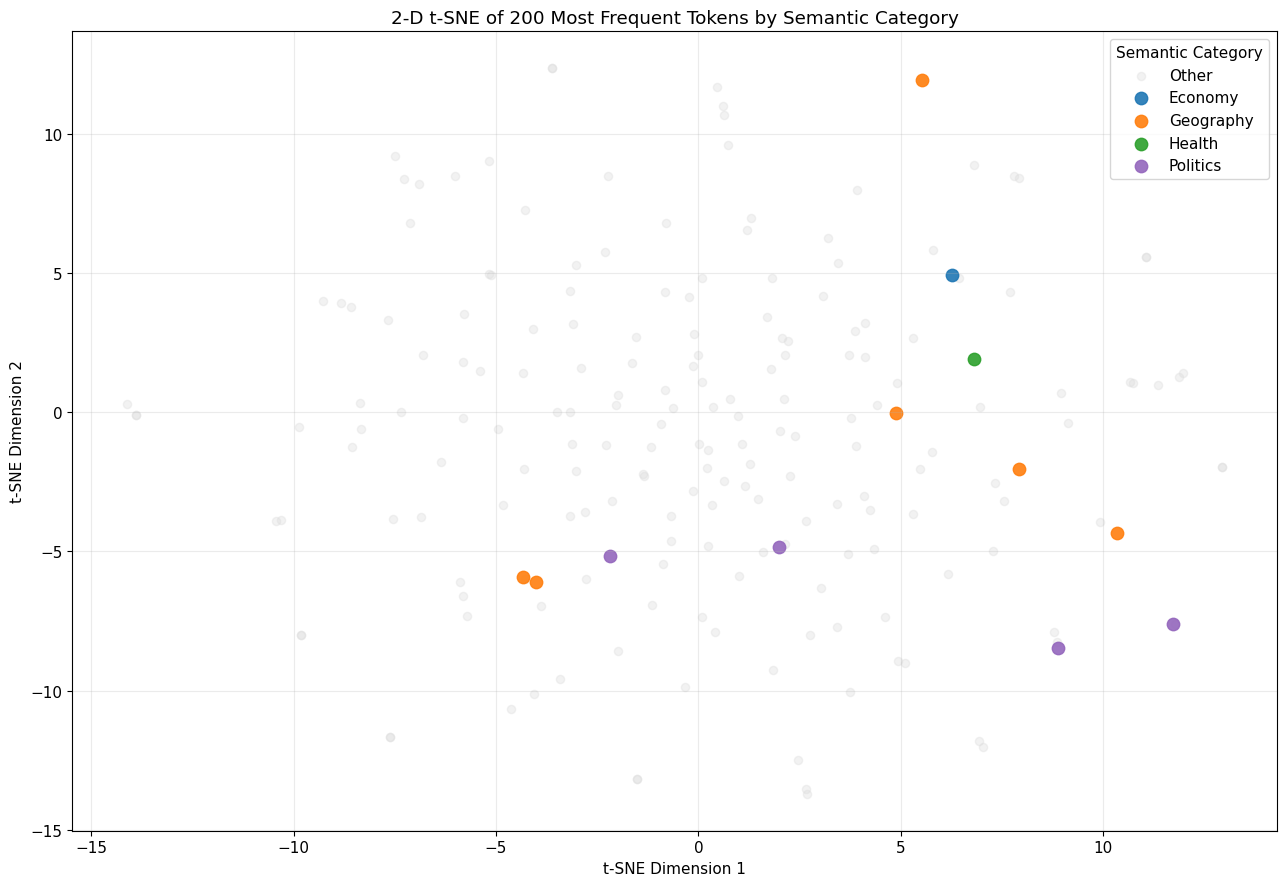

In [54]:
# -----------------------------------------
# 2-D t-SNE of frequent tokens by semantic category
# (including "other") - FIXED
# -----------------------------------------
top_200_words = [w for w, _ in freq_counter_clean.most_common(200) if w in word2idx_clean][:200]
top_200_ids = [word2idx_clean[w] for w in top_200_words]
top_200_vectors = ppmi_matrix[top_200_ids]

# Normalize category names to avoid case-matching issues
cats = [str(token_semantic_category(w)).strip().lower() for w in top_200_words]
unique_cats = sorted(set(cats))

print("Categories present:", unique_cats)

# Reduce dimensionality
svd_components = min(50, top_200_vectors.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_components, random_state=SEED)
top_200_reduced = svd.fit_transform(top_200_vectors)

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=25,
    init="pca",
    learning_rate="auto"
)
top_200_2d = tsne.fit_transform(top_200_reduced)

# Color map
color_map = {
    "economy": "tab:blue",
    "geography": "tab:orange",
    "health": "tab:green",
    "politics": "tab:purple",
    "sports": "tab:red",
    "international": "tab:brown",
    "other": "gainsboro"
}

plt.figure(figsize=(13, 9))

# Plot "other" first so it stays in the background
if "other" in unique_cats:
    idxs_other = [i for i, c in enumerate(cats) if c == "other"]
    plt.scatter(
        top_200_2d[idxs_other, 0],
        top_200_2d[idxs_other, 1],
        s=35,
        alpha=0.35,
        c=color_map["other"],
        label="Other"
    )

# Plot remaining categories on top
for cat in unique_cats:
    if cat == "other":
        continue

    idxs = [i for i, c in enumerate(cats) if c == cat]
    plt.scatter(
        top_200_2d[idxs, 0],
        top_200_2d[idxs, 1],
        s=80,
        alpha=0.9,
        c=color_map.get(cat, "gray"),
        label=cat.capitalize()
    )

plt.title("2-D t-SNE of 200 Most Frequent Tokens by Semantic Category")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Semantic Category")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Skip-gram data/model/training helpers

In [59]:
def build_vocab_from_sequences(sequences, max_vocab=10000):
    counter = Counter(tok for seq in sequences for tok in seq)
    most_common = [w for w, _ in counter.most_common(max_vocab)]
    idx2word = [UNK_TOKEN] + most_common
    word2idx = {w: i for i, w in enumerate(idx2word)}

    total_tokens = sum(counter.values())
    top_tokens_sum = sum(counter[w] for w in most_common)
    unk_count = max(1, total_tokens - top_tokens_sum)

    freqs = np.zeros(len(idx2word), dtype=np.float64)
    freqs[0] = unk_count
    for i, w in enumerate(most_common, start=1):
        freqs[i] = counter[w]

    return word2idx, idx2word, counter, freqs

def map_sequence(tokens, word2idx):
    unk_id = word2idx[UNK_TOKEN]
    return [word2idx.get(tok, unk_id) for tok in tokens]

def build_positive_pairs(sequences, word2idx, window_size=5):
    centers = []
    contexts = []

    for seq in tqdm(sequences, desc="Building positive skip-gram pairs"):
        ids = map_sequence(seq, word2idx)
        n = len(ids)

        for i, center in enumerate(ids):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)

            for j in range(left, right):
                if i == j:
                    continue
                centers.append(center)
                contexts.append(ids[j])

    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

class SkipGramDataset(Dataset):
    def __init__(self, centers, contexts):
        self.centers = centers
        self.contexts = contexts

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.centers[idx], self.contexts[idx]

class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)

        nn.init.uniform_(self.center_embeddings.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.zeros_(self.context_embeddings.weight)

    def forward(self, center_ids, pos_context_ids, neg_context_ids):
        v = self.center_embeddings(center_ids)             # [B, d]
        u_pos = self.context_embeddings(pos_context_ids)   # [B, d]
        u_neg = self.context_embeddings(neg_context_ids)   # [B, K, d]

        pos_scores = torch.sum(v * u_pos, dim=1)           # [B]
        neg_scores = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)  # [B, K]

        loss = -F.logsigmoid(pos_scores) - torch.sum(F.logsigmoid(-neg_scores), dim=1)
        return loss.mean()

    def averaged_embeddings(self):
        return ((self.center_embeddings.weight.data + self.context_embeddings.weight.data) / 2.0).detach().cpu().numpy()

def train_skipgram_experiment(
    sequences,
    exp_name,
    embed_dim=100,
    window_size=5,
    negative_samples=10,
    lr=1e-3,
    batch_size=1024,
    epochs=5,
    max_vocab=10000
):
    print(f"\n=== Training {exp_name} ===")

    word2idx, idx2word, counter, freqs = build_vocab_from_sequences(sequences, max_vocab=max_vocab)
    vocab_size = len(idx2word)

    centers, contexts = build_positive_pairs(sequences, word2idx, window_size=window_size)
    dataset = SkipGramDataset(centers, contexts)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    noise_dist = np.power(freqs, 0.75)
    noise_dist = noise_dist / noise_dist.sum()
    noise_dist = torch.tensor(noise_dist, dtype=torch.float32, device=DEVICE)

    model = SkipGramNegSampling(vocab_size, embed_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    step_losses = []
    epoch_losses = []
    global_step = 0

    print("Vocab size:", vocab_size)
    print("Positive pairs:", len(dataset))

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        seen = 0

        pbar = tqdm(dataloader, desc=f"{exp_name} | epoch {epoch+1}/{epochs}")
        for center_batch, pos_batch in pbar:
            center_batch = center_batch.to(DEVICE)
            pos_batch = pos_batch.to(DEVICE)

            neg_batch = torch.multinomial(
                noise_dist,
                num_samples=center_batch.size(0) * negative_samples,
                replacement=True
            ).view(center_batch.size(0), negative_samples)

            optimizer.zero_grad()
            loss = model(center_batch, pos_batch, neg_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * center_batch.size(0)
            seen += center_batch.size(0)

            global_step += 1
            if global_step % 100 == 0:
                step_losses.append((global_step, loss.item()))

            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / seen
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - average loss: {epoch_loss:.4f}")

    embeddings = model.averaged_embeddings().astype(np.float32)

    return {
        "name": exp_name,
        "model": model,
        "embeddings": embeddings,
        "word2idx": word2idx,
        "idx2word": idx2word,
        "counter": counter,
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
    }

print("Skip-gram model, dataset, and training utilities loaded successfully.")

Skip-gram model, dataset, and training utilities loaded successfully.


### Prepare cleaned sequences

In [60]:
cleaned_sequences = [
    sent for article in articles
    for sent in article["cleaned_sentences"]
    if len(sent) >= 2
]

raw_sequences = [
    sent for article in articles
    for sent in article["raw_sentences"]
    if len(sent) >= 2
]

print("Cleaned training sequences:", len(cleaned_sequences))
print("Raw training sequences:", len(raw_sequences))

Cleaned training sequences: 1090
Raw training sequences: 1069


## Train C3 (main required cleaned model)

In [61]:
c3 = train_skipgram_experiment(
    sequences=cleaned_sequences,
    exp_name="C3_skipgram_cleaned_d100",
    embed_dim=100,
    window_size=WINDOW_SIZE,
    negative_samples=NEGATIVE_SAMPLES,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    max_vocab=MAX_VOCAB
)

np.save("embeddings_w2v.npy", c3["embeddings"])

with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(c3["word2idx"], f, ensure_ascii=False, indent=2)

print("Saved embeddings_w2v.npy successfully.")
print("Updated word2idx.json successfully.")


=== Training C3_skipgram_cleaned_d100 ===


Building positive skip-gram pairs: 100%|██████████| 1090/1090 [00:00<00:00, 36747.78it/s]


Vocab size: 4387
Positive pairs: 308720


C3_skipgram_cleaned_d100 | epoch 1/5: 100%|██████████| 302/302 [00:01<00:00, 224.59it/s, loss=3.4374]


Epoch 1/5 - average loss: 4.7599


...

Epoch 3/5 - average loss: 3.2355


C3_skipgram_cleaned_d100 | epoch 4/5: 100%|██████████| 302/302 [00:01<00:00, 292.99it/s, loss=3.2252]


Epoch 4/5 - average loss: 3.2230


C3_skipgram_cleaned_d100 | epoch 5/5: 100%|██████████| 302/302 [00:01<00:00, 285.76it/s, loss=3.1849]


Epoch 5/5 - average loss: 3.2161
Saved embeddings_w2v.npy successfully.
Updated word2idx.json successfully.


## Plot C3 loss curves

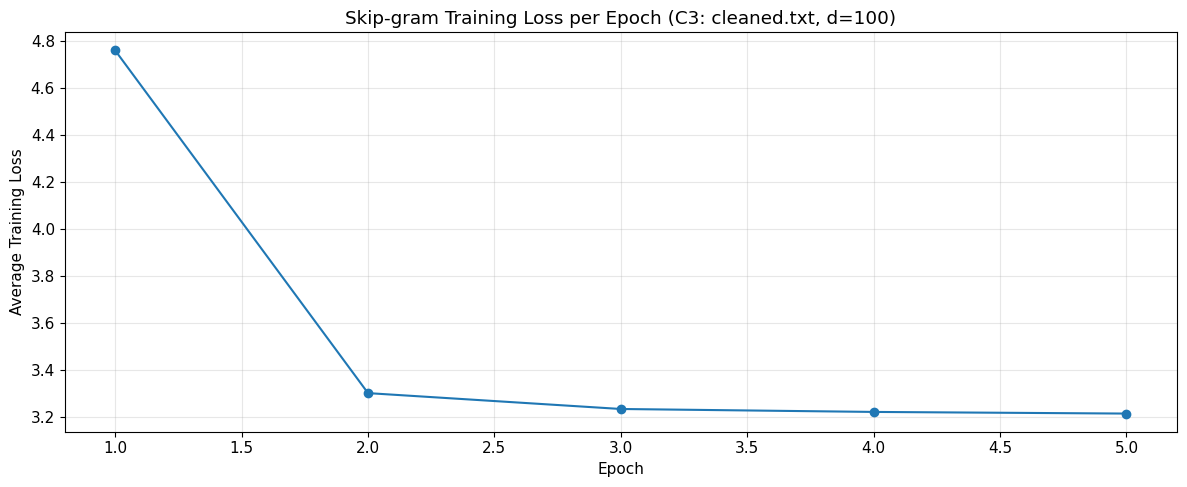

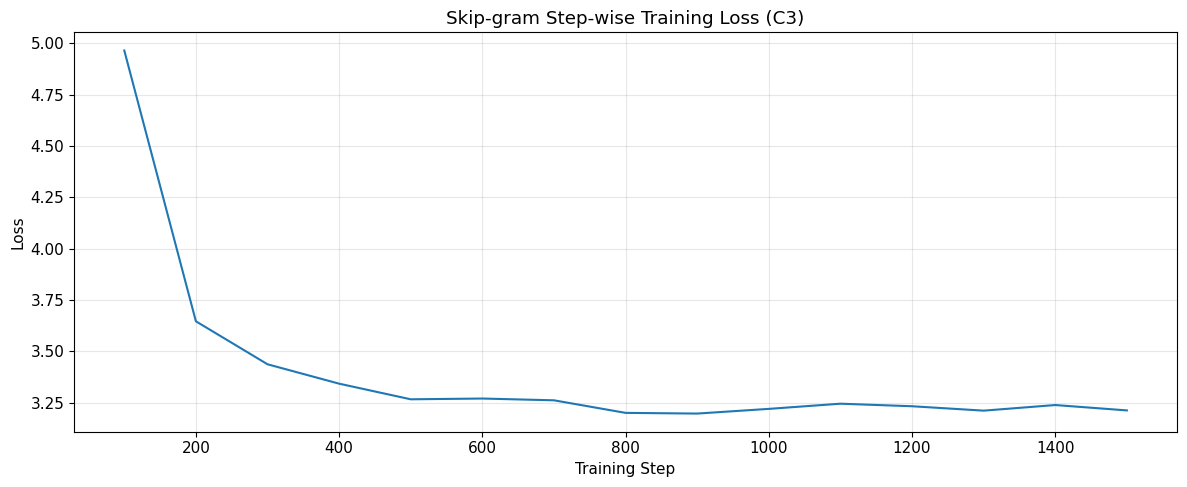

Loss curves generated successfully.


In [62]:
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(c3["epoch_losses"]) + 1), c3["epoch_losses"], marker="o")
plt.title("Skip-gram Training Loss per Epoch (C3: cleaned.txt, d=100)")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if c3["step_losses"]:
    steps, losses = zip(*c3["step_losses"])
    plt.figure(figsize=(12, 5))
    plt.plot(steps, losses)
    plt.title("Skip-gram Step-wise Training Loss (C3)")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Loss curves generated successfully.")

## Embedding evaluation utilities


In [63]:
def nearest_neighbors_embedding(embeddings, word2idx, idx2word, query_word, top_k=10):
    if query_word not in word2idx:
        return [("<<OOV>>", 0.0)]

    emb_norm = normalize_rows(embeddings)
    qid = word2idx[query_word]
    sims = emb_norm @ emb_norm[qid]
    sims[qid] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

def analogy_topk(embeddings, word2idx, idx2word, a, b, c, top_k=3):
    missing = [w for w in [a, b, c] if w not in word2idx]
    if missing:
        return [("<<OOV>>", 0.0)]

    emb_norm = normalize_rows(embeddings)
    target = emb_norm[word2idx[b]] - emb_norm[word2idx[a]] + emb_norm[word2idx[c]]

    sims = emb_norm @ target
    for w in [a, b, c]:
        sims[word2idx[w]] = -1.0

    top_ids = np.argsort(-sims)[:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_ids]

print("Evaluation utilities loaded successfully.")

Evaluation utilities loaded successfully.


## Required nearest neighbours for main mode

In [64]:
REQUIRED_QUERY_WORDS = [
    "پاکستان",
    "حکومت",
    "عدالت",
    "معیشت",
    "فوج",
    "صحت",
    "تعلیم",
    "آبادی"
]

print("Top-10 nearest neighbours for required query words")
print("=" * 60)

for q in REQUIRED_QUERY_WORDS:
    print(f"\nQuery word: {q}")
    results = nearest_neighbors_embedding(
        c3["embeddings"],
        c3["word2idx"],
        c3["idx2word"],
        q,
        top_k=10
    )
    for w, s in results:
        print(f"  {w:15s} {s:.4f}")

Top-10 nearest neighbours for required query words

Query word: پاکستان
  ذریعہ           0.9526
  ،تصویر          0.9356
  کا              0.9058
  صوبہ            0.8821
  وزیر            0.8315
  پاکستا          0.8249
  پنجاب           0.7810
  صدر             0.7779
  پختونخوا        0.7708
  حکومت           0.7681

Query word: حکومت
  پنجاب           0.8213
  پاکستا          0.8124
  فوج             0.7791
  پاکستان         0.7681
  وزیر            0.7607
  شہر             0.7463
  صوبہ            0.7372
  اعظم            0.7020
  خارجہ           0.6934
  انڈیا           0.6925

Query word: عدالت
  ماہ             0.8779
  کارروا          0.8702
  قبل             0.8587
  بامشقت          0.8369
  رک              0.8367
  پانچ            0.8365
  دفعہ            0.8359
  تین             0.8275
  بینچ            0.8250
  مارشل           0.8225

Query word: معیشت
  بہتری،          0.9975
  نفیس            0.9970
  ترقی            0.9969
  بنائی۔          0.9969
  کنٹینرز         0.9

## Analogy evaluation

In [65]:
ANALOGIES = [
    ("حکومت", "وزیر", "عدالت"),
    ("عدالت", "جج", "حکومت"),
    ("صحت", "ہسپتال", "تعلیم"),
    ("تعلیم", "استاد", "صحت"),
    ("فوج", "دفاع", "عدالت"),
    ("پاکستان", "حکومت", "بھارت"),
    ("کرکٹ", "میچ", "ٹیم"),
    ("ڈاکٹر", "ہسپتال", "مریض"),
    ("بینک", "معیشت", "روپے"),
    ("امریکہ", "ایران", "روس"),
]

valid_analogies = []
skipped_analogies = []

for a, b, c in ANALOGIES:
    if a in c3["word2idx"] and b in c3["word2idx"] and c in c3["word2idx"]:
        valid_analogies.append((a, b, c))
    else:
        skipped_analogies.append((a, b, c))

print(f"Valid analogies: {len(valid_analogies)} / {len(ANALOGIES)}")
if skipped_analogies:
    print("Skipped analogies due to OOV words:")
    for item in skipped_analogies:
        print(" ", item)

print("\nTop-3 analogy predictions")
print("=" * 60)

for a, b, c in valid_analogies:
    print(f"\n{a} : {b} :: {c} : ?")
    preds = analogy_topk(
        c3["embeddings"],
        c3["word2idx"],
        c3["idx2word"],
        a, b, c,
        top_k=3
    )
    for w, s in preds:
        print(f"  {w:15s} {s:.4f}")

Valid analogies: 8 / 10
Skipped analogies due to OOV words:
  ('تعلیم', 'استاد', 'صحت')
  ('پاکستان', 'حکومت', 'بھارت')

Top-3 analogy predictions

حکومت : وزیر :: عدالت : ?
  بامشقت          1.0110
  ماہ             1.0010
  جنوری           0.9949

عدالت : جج :: حکومت : ?
  پاکستا          1.0571
  پختونخوا        1.0432
  صوبہ            1.0369

صحت : ہسپتال :: تعلیم : ?
  عملے            0.9749
  صاحب            0.9740
  حملہ            0.9729

فوج : دفاع :: عدالت : ?
  ضمانت           1.2973
  غیر             1.2908
  قانو            1.2678

کرکٹ : میچ :: ٹیم : ?
  ضوابط           1.0062
  صبح             1.0058
  جگہ             1.0049

ڈاکٹر : ہسپتال :: مریض : ?
  لینے            1.2571
  ہر              1.2506
  سلسلہ           1.2469

بینک : معیشت :: روپے : ?
  ارب             0.9124
  قید             0.8850
  ہزار            0.8782

امریکہ : ایران :: روس : ?
  سن              1.2217
  تصور            1.2212
  جلا             1.2212


## Train C2 and C4 for comparison

In [66]:
c2 = train_skipgram_experiment(
    sequences=raw_sequences,
    exp_name="C2_skipgram_raw_d100",
    embed_dim=100,
    window_size=WINDOW_SIZE,
    negative_samples=NEGATIVE_SAMPLES,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    max_vocab=MAX_VOCAB
)

c4 = train_skipgram_experiment(
    sequences=cleaned_sequences,
    exp_name="C4_skipgram_cleaned_d200",
    embed_dim=200,
    window_size=WINDOW_SIZE,
    negative_samples=NEGATIVE_SAMPLES,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    max_vocab=MAX_VOCAB
)

c1 = {
    "name": "C1_PPMI_baseline",
    "embeddings": ppmi_matrix,
    "word2idx": word2idx_clean,
    "idx2word": idx2word_clean
}

conditions = {
    "C1": c1,
    "C2": c2,
    "C3": c3,
    "C4": c4
}

print("All four conditions prepared successfully.")


=== Training C2_skipgram_raw_d100 ===


Building positive skip-gram pairs: 100%|██████████| 1069/1069 [00:00<00:00, 33636.49it/s]


Vocab size: 5005
Positive pairs: 320346


C2_skipgram_raw_d100 | epoch 1/5: 100%|██████████| 313/313 [00:01<00:00, 205.33it/s, loss=3.4152]


Epoch 1/5 - average loss: 4.7794


...

Epoch 3/5 - average loss: 3.2264


C4_skipgram_cleaned_d200 | epoch 4/5: 100%|██████████| 302/302 [00:01<00:00, 257.31it/s, loss=3.2068]


Epoch 4/5 - average loss: 3.2154


C4_skipgram_cleaned_d200 | epoch 5/5: 100%|██████████| 302/302 [00:01<00:00, 261.03it/s, loss=3.1151]

Epoch 5/5 - average loss: 3.1861
All four conditions prepared successfully.


## Hyperparameter display for C1–C4

In [67]:
hyperparam_df = pd.DataFrame([
    {"Condition": "C1", "Method": "PPMI baseline", "Embedding_Dim": ppmi_matrix.shape[1]},
    {"Condition": "C2", "Method": "Skip-gram on raw.txt", "Embedding_Dim": 100},
    {"Condition": "C3", "Method": "Skip-gram on cleaned.txt", "Embedding_Dim": 100},
    {"Condition": "C4", "Method": "Skip-gram on cleaned.txt", "Embedding_Dim": 200},
])

print("Part 1 condition setup")
display(hyperparam_df)

Part 1 condition setup


,Condition,Method,Embedding_Dim
0,C1,PPMI baseline,4387
1,C2,Skip-gram on raw.txt,100
2,C3,Skip-gram on cleaned.txt,100
3,C4,Skip-gram on cleaned.txt,200


## Top-5 neighbours for 5 query words across C1–C4

In [68]:
FIVE_QUERY_WORDS = ["پاکستان", "حکومت", "عدالت", "معیشت", "فوج"]

def print_top5_for_queries(result_dict, query_words):
    emb = result_dict["embeddings"]
    word2idx = result_dict["word2idx"]
    idx2word = result_dict["idx2word"]

    for q in query_words:
        print(f"\n{q}")
        for w, s in nearest_neighbors_embedding(emb, word2idx, idx2word, q, top_k=5):
            print(f"  {w:15s} {s:.4f}")

for cid, result in conditions.items():
    print("\n" + "=" * 70)
    print(f"{cid} - {result['name']}")
    print("=" * 70)
    print_top5_for_queries(result, FIVE_QUERY_WORDS)


C1 - C1_PPMI_baseline

پاکستان
  کے              0.2382
  میں             0.2018
  انٹرنیشنل       0.1940
  کی              0.1910
  انڈیا           0.1888

حکومت
  طالبان          0.1967
  صوبا            0.1756
  نے              0.1704
  نااہل           0.1564
  سیلف            0.1546

عدالت
  کورٹ            0.2016
  ضمانت           0.1987
  سماعت           0.1978
  نے              0.1937
  مجوکہ           0.1878

معیشت
  عروج            0.6904
  پذیر            0.6693
  ترقی            0.6381
  بہتری،          0.5772
  کنٹینرز         0.4850

فوج
  پاکستا          0.2968
  گھیرے           0.2229
  مک              0.2195
  رینک            0.2027
  شعبہ            0.1974

C2 - C2_skipgram_raw_d100

پاکستان
  IMAGES          0.9784
  GETTY           0.9758
  ذریعہ           0.9717
  /               0.9589
  ،تصویر          0.9566

حکومت
  پنجاب           0.6827
  شہر             0.6155
  لاہور           0.5589
  فوج             0.5043
  صوبہ            0.4926

عدالت
  متعلق          

## MRR Comparison

In [69]:
MANUAL_PAIRS = [
    ("پاکستان", "بھارت"),
    ("حکومت", "وزیر"),
    ("عدالت", "جج"),
    ("معیشت", "بینک"),
    ("فوج", "دفاع"),
    ("صحت", "ہسپتال"),
    ("تعلیم", "استاد"),
    ("ڈاکٹر", "مریض"),
    ("کرکٹ", "میچ"),
    ("ٹیم", "کھلاڑی"),
    ("وزیراعظم", "حکومت"),
    ("قانون", "عدالت"),
    ("ویکسین", "بیماری"),
    ("روپے", "ڈالر"),
    ("یونیورسٹی", "تعلیم"),
    ("امریکہ", "روس"),
    ("ایران", "امریکہ"),
    ("نجکاری", "حصص"),
    ("سولر", "بجلی"),
    ("طالبان", "افغانستان"),
]

def reciprocal_rank(matrix, word2idx, idx2word, query, gold):
    if query not in word2idx or gold not in word2idx:
        return None

    matrix_norm = normalize_rows(matrix)
    qid = word2idx[query]
    gid = word2idx[gold]

    sims = matrix_norm @ matrix_norm[qid]
    sims[qid] = -1.0

    ranked_ids = np.argsort(-sims)
    rank_positions = np.where(ranked_ids == gid)[0]

    if len(rank_positions) == 0:
        return 0.0

    rank = rank_positions[0] + 1
    return 1.0 / rank

def compute_mrr_verbose(matrix, word2idx, idx2word, pairs):
    rrs = []
    used_pairs = []
    skipped_pairs = []

    for query, gold in pairs:
        if query not in word2idx or gold not in word2idx:
            skipped_pairs.append((query, gold))
            continue

        rr = reciprocal_rank(matrix, word2idx, idx2word, query, gold)
        if rr is not None:
            rrs.append(rr)
            used_pairs.append((query, gold, rr))

    mrr = float(np.mean(rrs)) if rrs else 0.0
    return mrr, used_pairs, skipped_pairs

comparison_rows = []

for cid, result in conditions.items():
    mrr, used_pairs, skipped_pairs = compute_mrr_verbose(
        result["embeddings"],
        result["word2idx"],
        result["idx2word"],
        MANUAL_PAIRS
    )

    comparison_rows.append({
        "Condition": cid,
        "Description": result["name"],
        "MRR": round(mrr, 6),
        "Used_Pairs": len(used_pairs),
        "Skipped_Pairs": len(skipped_pairs)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("MRR", ascending=False)

print("Condition comparison with MRR")
display(comparison_df)

Condition comparison with MRR


,Condition,Description,MRR,Used_Pairs,Skipped_Pairs
0,C1,C1_PPMI_baseline,0.025708,16,4
2,C3,C3_skipgram_cleaned_d100,0.022937,16,4
3,C4,C4_skipgram_cleaned_d200,0.017360,16,4
1,C2,C2_skipgram_raw_d100,0.011912,15,5


### Plot of the conditions

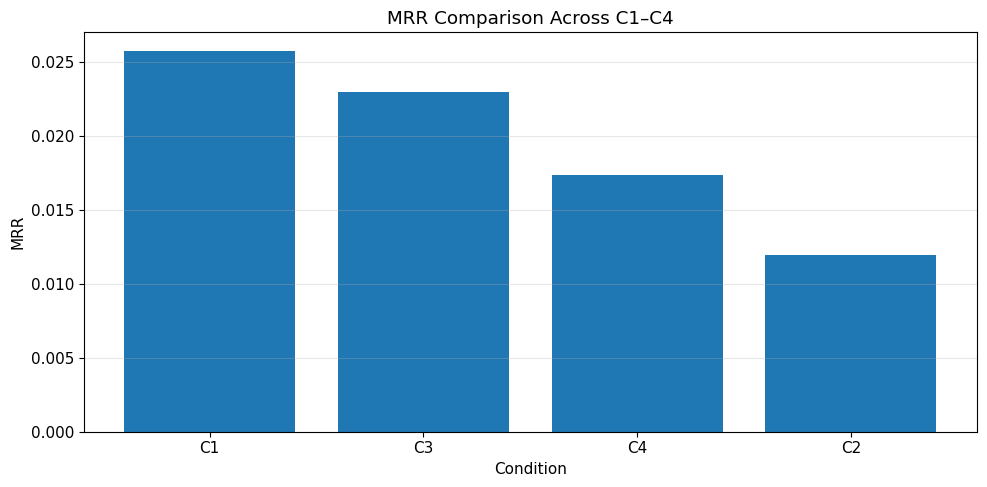

MRR comparison plot generated successfully.


In [70]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Condition"], comparison_df["MRR"])
plt.title("MRR Comparison Across C1–C4")
plt.xlabel("Condition")
plt.ylabel("MRR")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("MRR comparison plot generated successfully.")

In [71]:
best_row = comparison_df.iloc[0]

print("Part 1 Condition Comparison Summary")
print("-" * 50)
print(f"Best condition by MRR: {best_row['Condition']}")
print(f"Description: {best_row['Description']}")
print(f"MRR: {best_row['MRR']:.6f}")
print()

print("Observations:")
print("1. C1 uses PPMI-based co-occurrence vectors.")
print("2. C2 uses Skip-gram trained on raw.txt.")
print("3. C3 uses Skip-gram trained on cleaned.txt.")
print("4. C4 uses the same cleaned corpus as C3 but doubles embedding dimension to 200.")
print("5. Increasing embedding dimension may help if enough meaningful context exists in the corpus.")

Part 1 Condition Comparison Summary
--------------------------------------------------
Best condition by MRR: C1
Description: C1_PPMI_baseline
MRR: 0.025708

Observations:
1. C1 uses PPMI-based co-occurrence vectors.
2. C2 uses Skip-gram trained on raw.txt.
3. C3 uses Skip-gram trained on cleaned.txt.
4. C4 uses the same cleaned corpus as C3 but doubles embedding dimension to 200.
5. Increasing embedding dimension may help if enough meaningful context exists in the corpus.
